In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION'

In [3]:
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True  # Optimize backend performance
torch.cuda.reset_peak_memory_stats()

In [4]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
root_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION/SOLAR_PANEL_DATASET'
train_images_dir = os.path.join(root_dir, 'train/images')
train_masks_dir = os.path.join(root_dir, 'train/masks')
val_images_dir = os.path.join(root_dir, 'val/images')
val_masks_dir = os.path.join(root_dir, 'val/masks')

# Custom Dataset
class RooftopDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.transform = transform
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_filenames[idx])
        
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = mask.astype(np.float32) / 255.0
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask).unsqueeze(0)  # Ensure mask shape [1, H, W]
        
        return image, mask.squeeze(0)  # Ensure mask shape [H, W]

# Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = RooftopDataset(train_images_dir, train_masks_dir, transform)
val_dataset = RooftopDataset(val_images_dir, val_masks_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

# U-Net Model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder = nn.ModuleList([
            conv_block(3, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256)
        ])
        
        self.pool = nn.MaxPool2d(2)
        
        self.upconv = nn.ModuleList([
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        ])
        
        self.decoder = nn.ModuleList([
            conv_block(256, 128),
            conv_block(128, 64),
            conv_block(64, 32),
            conv_block(32, 16)
        ])
        
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        enc_outs = []
        for enc in self.encoder:
            x = enc(x)
            enc_outs.append(x)
            x = self.pool(x)
        
        for i in range(4):
            x = self.upconv[i](x)
            enc_out = enc_outs[-(i+2)]
            if x.shape[2:] != enc_out.shape[2:]:
                x = nn.functional.interpolate(x, size=enc_out.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, enc_out], dim=1)
            x = self.decoder[i](x)
        
        return torch.sigmoid(self.final_conv(x))

# Training Setup
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
def train(model, train_loader, val_loader, epochs=50):
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)  # Ensure correct shape [B, 1, H, W]
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    
    torch.save(model.state_dict(), "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION/results/unet/unet_rooftop_50_2.pth")
    torch.save(model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION/results/unet/full_unet_rooftop_50_2.pth")
    
    print("Model saved!")

train(model, train_loader, val_loader,epochs=50)

Using device: cuda
Epoch 1/50, Loss: 0.6705
Epoch 2/50, Loss: 0.5958
Epoch 3/50, Loss: 0.5139
Epoch 4/50, Loss: 0.3179
Epoch 5/50, Loss: 0.1599
Epoch 6/50, Loss: 0.1435
Epoch 7/50, Loss: 0.1355
Epoch 8/50, Loss: 0.1277
Epoch 9/50, Loss: 0.1167
Epoch 10/50, Loss: 0.1107
Epoch 11/50, Loss: 0.1129
Epoch 12/50, Loss: 0.1038
Epoch 13/50, Loss: 0.1000
Epoch 14/50, Loss: 0.0962
Epoch 15/50, Loss: 0.0932
Epoch 16/50, Loss: 0.0958
Epoch 17/50, Loss: 0.0940
Epoch 18/50, Loss: 0.0912
Epoch 19/50, Loss: 0.0883
Epoch 20/50, Loss: 0.0880
Epoch 21/50, Loss: 0.0877
Epoch 22/50, Loss: 0.0854
Epoch 23/50, Loss: 0.0829
Epoch 24/50, Loss: 0.0820
Epoch 25/50, Loss: 0.0810
Epoch 26/50, Loss: 0.0776
Epoch 27/50, Loss: 0.0779
Epoch 28/50, Loss: 0.0790
Epoch 29/50, Loss: 0.0802
Epoch 30/50, Loss: 0.0763
Epoch 31/50, Loss: 0.0711
Epoch 32/50, Loss: 0.0761
Epoch 33/50, Loss: 0.0759
Epoch 34/50, Loss: 0.0767
Epoch 35/50, Loss: 0.0706
Epoch 36/50, Loss: 0.0691
Epoch 37/50, Loss: 0.0705
Epoch 38/50, Loss: 0.0687
Ep

In [5]:
# Evaluation

def evaluate(model, val_loader):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            
            intersection = (preds * masks).sum()
            union = (preds + masks).sum() - intersection
            iou = intersection / (union + 1e-6)
            iou_scores.append(iou.item())
    
    print(f"Mean IoU Score: {np.mean(iou_scores):.4f}")
    return iou_scores


iou_score = evaluate(model, val_loader)

Mean IoU Score: 0.9166


In [1]:
losses = [0.6705,0.5958,0.5139,0.3179,0.1599,0.1435,0.1355,0.1277,0.1167,0.1107,0.1129,0.1038,0.1000,0.0962,0.0932,0.0958,0.0940,0.0912,0.0883,0.0880,0.0877,0.0854,0.0829,0.0820,0.0810,0.0776,0.0779,0.0790,0.0802,0.0763,0.0711,0.0761,0.0759,0.0767,0.0706,0.0691,0.0705,0.0687,0.0757,0.0700,0.0681,0.0673,0.0682,0.0666,0.0652,0.0661,0.0659,0.0629,0.0647,0.0626]

In [2]:
len(losses)

50

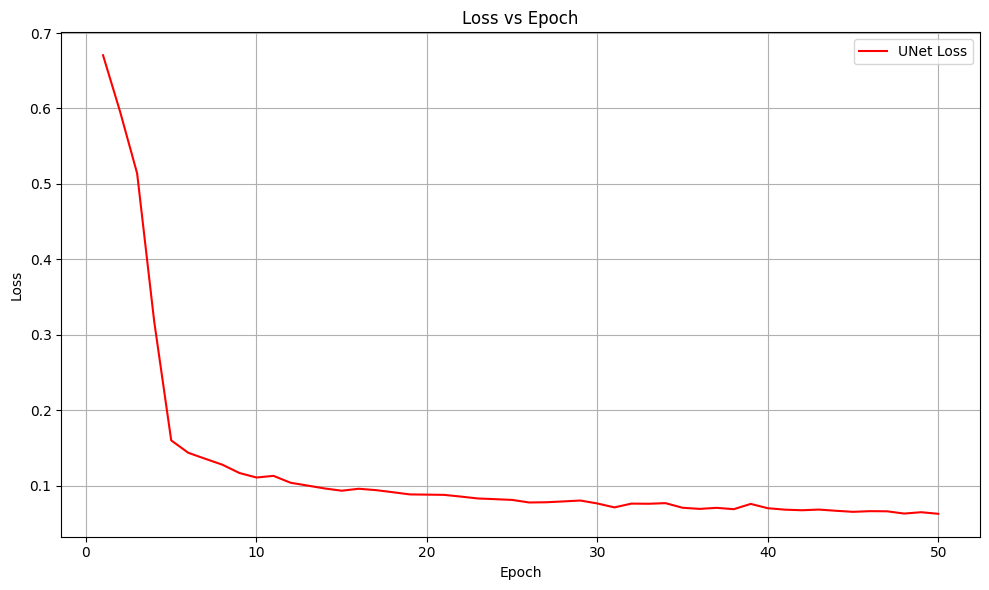

In [3]:
import matplotlib.pyplot as plt

unet_loss = losses
epochs = list(range(1,51))

plt.figure(figsize=(10, 6))
# plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.plot(epochs, unet_loss, label='UNet Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_SOLAR_PANEL_SEGMENTATION/results/unet/loss_vs_epoch_UNET_50.png')
plt.tight_layout()
plt.show()